# Part 4: 종합 실험 및 분석

## 이 노트북에서 다루는 내용
1. 모든 양자화 방법 종합 비교 (Baseline, Dynamic PTQ, Static PTQ, QAT)
2. Calibration 데이터 크기 실험 (Static PTQ)
3. QAT 에포크 수 실험
4. 종합 결과 시각화

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import copy
import time
import tempfile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.ao.quantization as quant
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN, QuantizableCNN

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
BATCH_SIZE = 128
EPOCHS = 10
QAT_EPOCHS = 5
LEARNING_RATE = 0.001
QAT_LEARNING_RATE = 0.0001
NUM_CLASSES = 10
SEED = 42
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습: {len(train_dataset):,}, 테스트: {len(test_dataset):,}")

학습: 50,000, 테스트: 10,000


## [2] 유틸리티 함수

In [3]:
def train_model(model, train_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


def train_qat(model, train_loader, epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"QAT Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


def test_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def get_model_size_mb(model):
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.pth')
    tmp_path = tmp.name
    tmp.close()
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb


def measure_inference_time(model, test_loader, device, num_batches=50):
    model.to(device)
    model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= 5: break
            _ = model(inputs.to(device))
    start = time.time()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= num_batches: break
            _ = model(inputs.to(device))
    return time.time() - start


def load_cnn_weights_to_quantizable(fp32_state_dict, num_classes=10):
    qmodel = QuantizableCNN(num_classes=num_classes)
    quant_sd = {}
    for key, value in fp32_state_dict.items():
        if key.startswith('features.'):
            quant_sd[key] = value
        elif key == 'classifier.0.weight':
            quant_sd['classifier.0.weight'] = value
        elif key == 'classifier.0.bias':
            quant_sd['classifier.0.bias'] = value
        elif key == 'classifier.3.weight':
            quant_sd['classifier.2.weight'] = value
        elif key == 'classifier.3.bias':
            quant_sd['classifier.2.bias'] = value
    qmodel.load_state_dict(quant_sd)
    return qmodel

## [3] Baseline 모델 학습

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES)
train_model(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)

model.to(DEVICE)
baseline_acc = test_model(model, test_loader, DEVICE)
baseline_size = get_model_size_mb(model)
print(f"\nBaseline 정확도: {baseline_acc:.2f}%, 크기: {baseline_size:.2f} MB")

fp32_state_dict = copy.deepcopy(model.cpu().state_dict())

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347

Baseline 정확도: 75.01%, 크기: 4.53 MB


## [4] 모든 양자화 방법 적용

In [5]:
# Dynamic PTQ
print(">> Dynamic PTQ")
dynamic_model = quant.quantize_dynamic(copy.deepcopy(model).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
dynamic_acc = test_model(dynamic_model, test_loader, 'cpu')
dynamic_size = get_model_size_mb(dynamic_model)
print(f"   정확도: {dynamic_acc:.2f}%, 크기: {dynamic_size:.2f} MB")

>> Dynamic PTQ
   정확도: 75.04%, 크기: 1.52 MB


In [6]:
# Static PTQ
print(">> Static PTQ (calibration: 100 batches)")
static_model = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)
static_model.eval()
static_model.fuse_model()
static_model.qconfig = quant.get_default_qconfig('fbgemm')
quant.prepare(static_model, inplace=True)
with torch.no_grad():
    for i, (inputs, _) in enumerate(train_loader):
        if i >= 100: break
        static_model(inputs)
quant.convert(static_model, inplace=True)
static_acc = test_model(static_model, test_loader, 'cpu')
static_size = get_model_size_mb(static_model)
print(f"   정확도: {static_acc:.2f}%, 크기: {static_size:.2f} MB")

>> Static PTQ (calibration: 100 batches)


c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


   정확도: 74.84%, 크기: 1.16 MB


In [7]:
# QAT
print(f">> QAT ({QAT_EPOCHS} epochs)")
qat_model = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)
qat_model.train()
qat_model.fuse_model()
qat_model.qconfig = quant.get_default_qat_qconfig('fbgemm')
quant.prepare_qat(qat_model, inplace=True)
train_qat(qat_model, train_loader, QAT_EPOCHS, QAT_LEARNING_RATE)
qat_model.eval()
qat_model = quant.convert(qat_model)
qat_acc = test_model(qat_model, test_loader, 'cpu')
qat_size = get_model_size_mb(qat_model)
print(f"   정확도: {qat_acc:.2f}%, 크기: {qat_size:.2f} MB")

>> QAT (5 epochs)
QAT Epoch 1/5, Loss: 0.0250
QAT Epoch 2/5, Loss: 0.0056
QAT Epoch 3/5, Loss: 0.0022
QAT Epoch 4/5, Loss: 0.0011
QAT Epoch 5/5, Loss: 0.0007
   정확도: 77.10%, 크기: 1.16 MB


## [5] 추론 시간 비교

In [8]:
model_cpu = copy.deepcopy(model).cpu()
baseline_time = measure_inference_time(model_cpu, test_loader, 'cpu')
dynamic_time = measure_inference_time(dynamic_model, test_loader, 'cpu')
static_time = measure_inference_time(static_model, test_loader, 'cpu')
qat_time = measure_inference_time(qat_model, test_loader, 'cpu')

print(f"Baseline: {baseline_time:.3f}s")
print(f"Dynamic:  {dynamic_time:.3f}s ({dynamic_time/baseline_time*100:.1f}%)")
print(f"Static:   {static_time:.3f}s ({static_time/baseline_time*100:.1f}%)")
print(f"QAT:      {qat_time:.3f}s ({qat_time/baseline_time*100:.1f}%)")

Baseline: 4.647s
Dynamic:  4.907s (105.6%)
Static:   1.984s (42.7%)
QAT:      1.930s (41.5%)


## [6] Calibration 데이터 크기 실험 (Static PTQ)

In [9]:
calib_sizes = [10, 25, 50, 100, 200, 390]
calib_results = []

for n_batches in calib_sizes:
    m = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)
    m.eval()
    m.fuse_model()
    m.qconfig = quant.get_default_qconfig('fbgemm')
    quant.prepare(m, inplace=True)
    with torch.no_grad():
        for i, (inputs, _) in enumerate(train_loader):
            if i >= n_batches: break
            m(inputs)
    quant.convert(m, inplace=True)
    acc = test_model(m, test_loader, 'cpu')
    n_samples = min(n_batches * BATCH_SIZE, 50000)
    calib_results.append((n_batches, n_samples, acc))
    print(f"{n_batches:>4} batches ({n_samples:>6} samples) → {acc:.2f}%")

  10 batches (  1280 samples) → 74.83%
  25 batches (  3200 samples) → 74.69%
  50 batches (  6400 samples) → 74.86%
 100 batches ( 12800 samples) → 74.91%
 200 batches ( 25600 samples) → 74.83%
 390 batches ( 49920 samples) → 74.74%


## [7] QAT 에포크 수 실험

In [10]:
qat_epoch_list = [1, 2, 3, 5, 10]
qat_epoch_results = []

for ep in qat_epoch_list:
    print(f"\n--- QAT {ep} epochs ---")
    m = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)
    m.train()
    m.fuse_model()
    m.qconfig = quant.get_default_qat_qconfig('fbgemm')
    quant.prepare_qat(m, inplace=True)
    train_qat(m, train_loader, ep, QAT_LEARNING_RATE)
    m.eval()
    m = quant.convert(m)
    acc = test_model(m, test_loader, 'cpu')
    qat_epoch_results.append((ep, acc))
    print(f"→ {acc:.2f}%")


--- QAT 1 epochs ---
QAT Epoch 1/1, Loss: 0.0248
→ 77.04%

--- QAT 2 epochs ---
QAT Epoch 1/2, Loss: 0.0254
QAT Epoch 2/2, Loss: 0.0055
→ 77.19%

--- QAT 3 epochs ---
QAT Epoch 1/3, Loss: 0.0254
QAT Epoch 2/3, Loss: 0.0059
QAT Epoch 3/3, Loss: 0.0023
→ 77.04%

--- QAT 5 epochs ---
QAT Epoch 1/5, Loss: 0.0254
QAT Epoch 2/5, Loss: 0.0055
QAT Epoch 3/5, Loss: 0.0022
QAT Epoch 4/5, Loss: 0.0011
QAT Epoch 5/5, Loss: 0.0007
→ 77.29%

--- QAT 10 epochs ---
QAT Epoch 1/10, Loss: 0.0246
QAT Epoch 2/10, Loss: 0.0054
QAT Epoch 3/10, Loss: 0.0023
QAT Epoch 4/10, Loss: 0.0011
QAT Epoch 5/10, Loss: 0.0006
QAT Epoch 6/10, Loss: 0.0004
QAT Epoch 7/10, Loss: 0.0003
QAT Epoch 8/10, Loss: 0.0002
QAT Epoch 9/10, Loss: 0.0001
QAT Epoch 10/10, Loss: 0.0001
→ 77.24%


## [8] 종합 결과 시각화

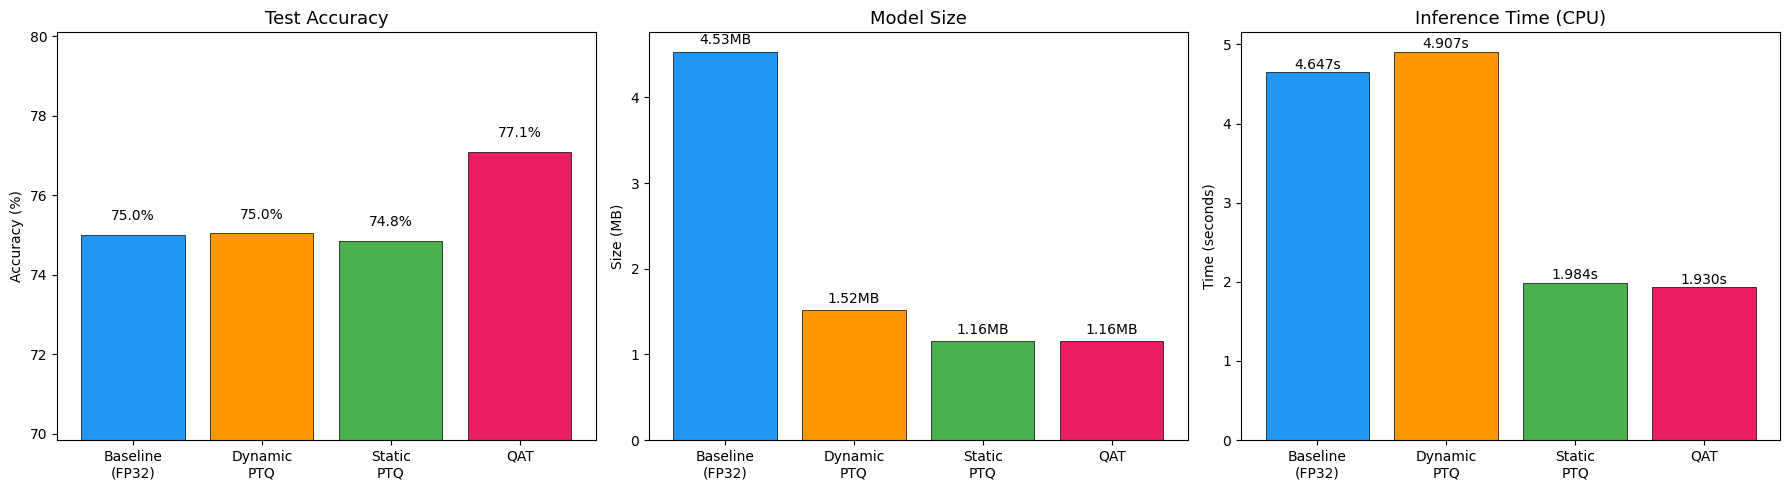

In [11]:
# 모든 방법 비교 (정확도 + 크기 + 속도)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['Baseline\n(FP32)', 'Dynamic\nPTQ', 'Static\nPTQ', 'QAT']
accs = [baseline_acc, dynamic_acc, static_acc, qat_acc]
sizes = [baseline_size, dynamic_size, static_size, qat_size]
times = [baseline_time, dynamic_time, static_time, qat_time]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

# 정확도
bars = axes[0].bar(methods, accs, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Test Accuracy', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(min(accs) - 5, max(accs) + 3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)

# 크기
bars = axes[1].bar(methods, sizes, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Model Size', fontsize=13)
axes[1].set_ylabel('Size (MB)')
for bar, s in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{s:.2f}MB', ha='center', va='bottom', fontsize=10)

# 속도
bars = axes[2].bar(methods, times, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('Inference Time (CPU)', fontsize=13)
axes[2].set_ylabel('Time (seconds)')
for bar, t in zip(bars, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{t:.3f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

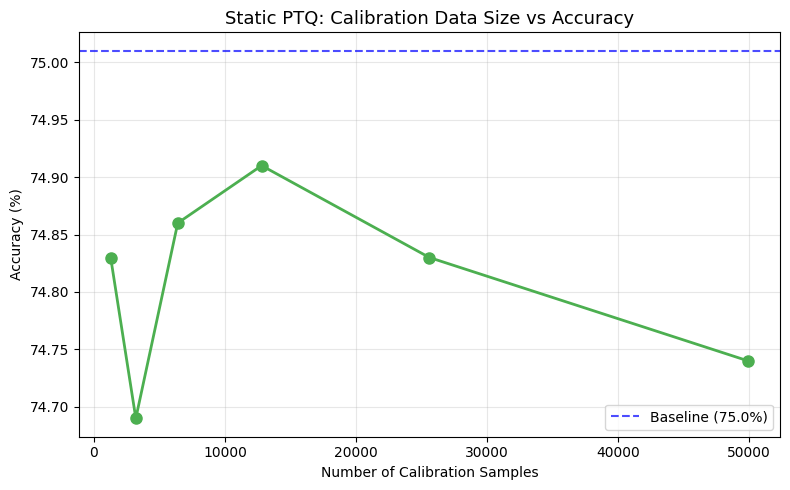

In [12]:
# Calibration 크기 실험
fig, ax = plt.subplots(figsize=(8, 5))
_, samples, cal_accs = zip(*calib_results)
ax.plot(samples, cal_accs, 'o-', color='#4CAF50', linewidth=2, markersize=8)
ax.axhline(y=baseline_acc, color='blue', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_acc:.1f}%)')
ax.set_title('Static PTQ: Calibration Data Size vs Accuracy', fontsize=13)
ax.set_xlabel('Number of Calibration Samples')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

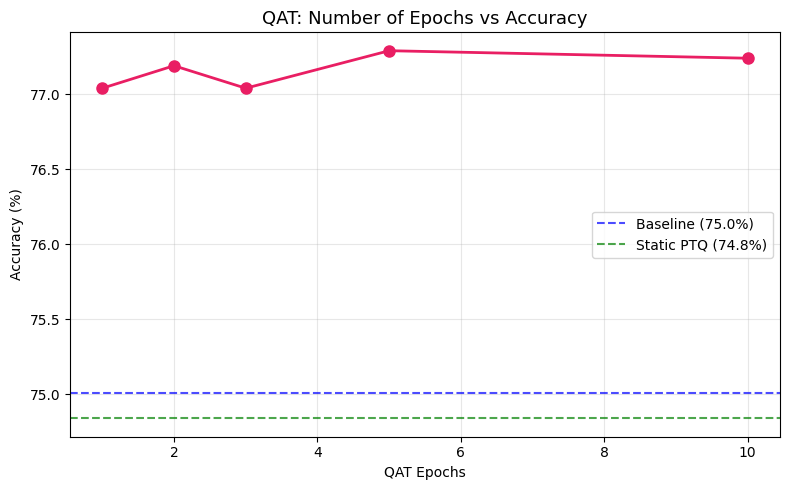

In [13]:
# QAT 에포크 실험
fig, ax = plt.subplots(figsize=(8, 5))
ep_list, ep_accs = zip(*qat_epoch_results)
ax.plot(ep_list, ep_accs, 'o-', color='#E91E63', linewidth=2, markersize=8)
ax.axhline(y=baseline_acc, color='blue', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_acc:.1f}%)')
ax.axhline(y=static_acc, color='green', linestyle='--', alpha=0.7, label=f'Static PTQ ({static_acc:.1f}%)')
ax.set_title('QAT: Number of Epochs vs Accuracy', fontsize=13)
ax.set_xlabel('QAT Epochs')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 최종 결과 요약

In [14]:
print("=" * 60)
print("Quantization 종합 실험 최종 결과")
print("=" * 60)
print(f"\n{'Method':<25} {'Accuracy':>10} {'Size (MB)':>10} {'Time (s)':>10}")
print("-" * 55)
print(f"{'Baseline (FP32)':<25} {baseline_acc:>9.2f}% {baseline_size:>9.2f} {baseline_time:>9.3f}")
print(f"{'Dynamic PTQ':<25} {dynamic_acc:>9.2f}% {dynamic_size:>9.2f} {dynamic_time:>9.3f}")
print(f"{'Static PTQ':<25} {static_acc:>9.2f}% {static_size:>9.2f} {static_time:>9.3f}")
print(f"{'QAT':<25} {qat_acc:>9.2f}% {qat_size:>9.2f} {qat_time:>9.3f}")

print(f"\n핵심 결론:")
print(f"- Dynamic PTQ: 가장 간단, Linear만 양자화 → 크기 감소 제한적")
print(f"- Static PTQ: 전체 양자화, calibration 필요 → 크기 대폭 감소")
print(f"- QAT: 학습 중 양자화 시뮬레이션 → 정확도 손실 최소화")
print(f"- Calibration 데이터 크기: 일정 수준 이상이면 정확도 수렴")
print(f"- QAT 에포크: 적은 에포크로도 효과적")

Quantization 종합 실험 최종 결과

Method                      Accuracy  Size (MB)   Time (s)
-------------------------------------------------------
Baseline (FP32)               75.01%      4.53     4.647
Dynamic PTQ                   75.04%      1.52     4.907
Static PTQ                    74.84%      1.16     1.984
QAT                           77.10%      1.16     1.930

핵심 결론:
- Dynamic PTQ: 가장 간단, Linear만 양자화 → 크기 감소 제한적
- Static PTQ: 전체 양자화, calibration 필요 → 크기 대폭 감소
- QAT: 학습 중 양자화 시뮬레이션 → 정확도 손실 최소화
- Calibration 데이터 크기: 일정 수준 이상이면 정확도 수렴
- QAT 에포크: 적은 에포크로도 효과적
